In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import os
import json
import re
from util import load_json
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report


In [49]:
def return_binary_classification(result):
    if "not" in result.lower() or "non" in result.lower():
        #print('0 == ', result)
        return 0
    elif "key case" in result.lower():
        print('1 == ', result)
        return 1
    else:
        print('ERROR: ', result)
        raise ValueError("Invalid classification")


def transalte_importance_score(file_name):
    if "i_1" in file_name:
        return 1
    else:
        return 0

def get_df(output_dir = './results_facts_openai/'):
    results = os.listdir(output_dir)

    data = []
    for result in results:
        #print(result)
        result_data = load_json(os.path.join(output_dir, result))
        syth_output = result_data["synthetizer_response"]
        ground_truth = transalte_importance_score(result)
        #print('BEFORE: ',result_data["synthetizer_response"])
        #print('AFTER: ',syth_output)
        data.append(
            {
                "classification": return_binary_classification(syth_output["classification"]),
                "ground_truth": ground_truth,
            }
        )

    df = pd.DataFrame(data)
    return df

def get_heatmap(df: pd.DataFrame, target_col: str, pred_col: str):
    """Plot and display a heatmap of the confusion matrix."""
    import seaborn as sns
    import matplotlib.pyplot as plt

    cm = confusion_matrix(df[target_col], df[pred_col], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


def get_metrics_binary(df):
    # Key Case vs. All
    # Ground truth: 1 for key case, 0 for not key case
    y_true = df['ground_truth']
    # Model predictions: 1 for key case, 0 for not key case
    y_pred = df['classification']

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="binary")
    recall = recall_score(y_true, y_pred, average="binary")
    f1 = f1_score(y_true, y_pred, average="binary")

    # Classification report for additional insights
    rreport = classification_report(y_true, y_pred, target_names=["Not Key Case", "Key Case"], output_dict=True)
    report = classification_report(y_true, y_pred, target_names=["Not Key Case", "Key Case"])

    # Extracting micro and macro F1 scores
    micro_f1 = rreport["accuracy"]  # Micro F1 is equivalent to accuracy in binary classification
    macro_f1 = rreport["macro avg"]["f1-score"]

    # Presenting results
    metrics = {

        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Micro F1": micro_f1,
        "Macro F1": macro_f1,
    }
    return metrics, report


In [50]:
output_dir = './results_facts/'
df = get_df(output_dir)
metrics, report = get_metrics_binary(df)
metrics

1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  ** KEY CASE

**
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 ==  KEY CASE
1 =

{'Accuracy': 0.428,
 'Precision': 0.25970149253731345,
 'Recall': 0.696,
 'F1 Score': 0.3782608695652174,
 'Micro F1': 0.428,
 'Macro F1': 0.4243156199677939}

In [51]:
print(report)

              precision    recall  f1-score   support

Not Key Case       0.77      0.34      0.47       375
    Key Case       0.26      0.70      0.38       125

    accuracy                           0.43       500
   macro avg       0.51      0.52      0.42       500
weighted avg       0.64      0.43      0.45       500



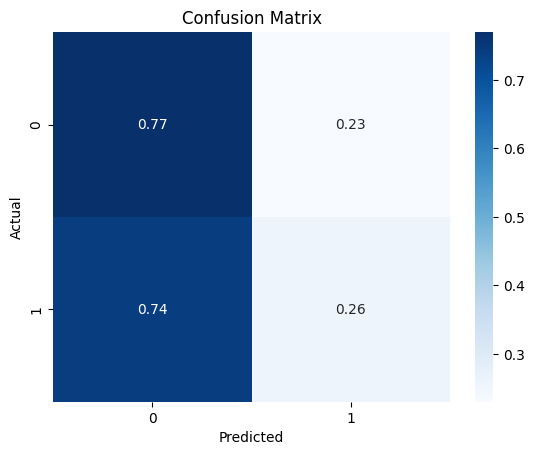

In [52]:
get_heatmap(df, "classification", "ground_truth",)